# Imports

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

# Load Dataset

In [62]:
df_dirty = pd.read_csv("Employee.csv")
df_dirty.head()

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1


# Data Quality Assessment

In [63]:
df_dirty.shape

(4653, 9)

The dataset has 9 columns and 4653 rows.

In [64]:
df_dirty.info()

<class 'pandas.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Education                  4653 non-null   str  
 1   JoiningYear                4653 non-null   int64
 2   City                       4653 non-null   str  
 3   PaymentTier                4653 non-null   int64
 4   Age                        4653 non-null   int64
 5   Gender                     4653 non-null   str  
 6   EverBenched                4653 non-null   str  
 7   ExperienceInCurrentDomain  4653 non-null   int64
 8   LeaveOrNot                 4653 non-null   int64
dtypes: int64(5), str(4)
memory usage: 327.3 KB


There are no missing values.

In [65]:
df_dirty.describe()

,JoiningYear,PaymentTier,Age,ExperienceInCurrentDomain,LeaveOrNot
count,4653.000000,4653.000000,4653.000000,4653.000000,4653.000000
mean,2015.062970,2.698259,29.393295,2.905652,0.343864
std,1.863377,0.561435,4.826087,1.558240,0.475047
min,2012.000000,1.000000,22.000000,0.000000,0.000000
25%,2013.000000,3.000000,26.000000,2.000000,0.000000
50%,2015.000000,3.000000,28.000000,3.000000,0.000000
75%,2017.000000,3.000000,32.000000,4.000000,1.000000
max,2018.000000,3.000000,41.000000,7.000000,1.000000


There is no values in the numerical features of the dataset that are less than zero.

In [66]:
df_dirty.duplicated().sum()

np.int64(1889)

There are 1889 duplicated rows in the dataset.

In [67]:
print("Unique Education values")
print(df_dirty.Education.unique())
print()
print("Unique City values")
print(df_dirty.City.unique())
print()
print("Unique Gender values")
print(df_dirty.Gender.unique())
print()
print("Unique Ever Benched values")
print(df_dirty.EverBenched.unique())



Unique Education values
<StringArray>
['Bachelors', 'Masters', 'PHD']
Length: 3, dtype: str

Unique City values
<StringArray>
['Bangalore', 'Pune', 'New Delhi']
Length: 3, dtype: str

Unique Gender values
<StringArray>
['Male', 'Female']
Length: 2, dtype: str

Unique Ever Benched values
<StringArray>
['No', 'Yes']
Length: 2, dtype: str


All the categorical features contain expected categories and are consistent

# Data Cleaning

In [68]:
print("Duplicaes before cleaning: ", (df_dirty.duplicated()).sum())
df_clean = df_dirty.copy()
df_clean = df_clean.drop_duplicates()

print("Duplicaes before cleaning: ",(df_clean.duplicated()).sum())

Duplicaes before cleaning:  1889
Duplicaes before cleaning:  0


# Exploratory Data Analysis

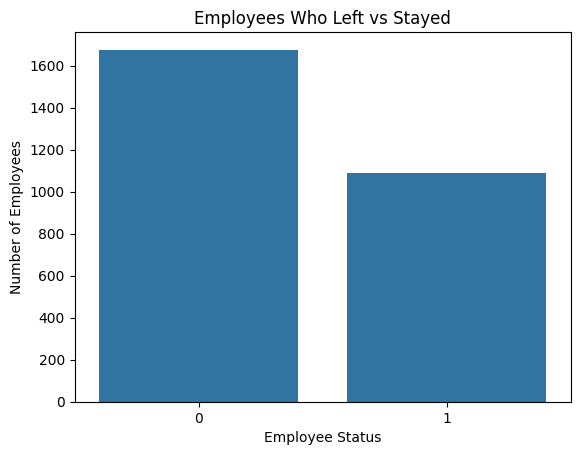

In [135]:
sns.countplot(data=df_clean, x="LeaveOrNot")

plt.xlabel("Employee Status")
plt.ylabel("Number of Employees")
plt.title("Employees Who Left vs Stayed")
plt.show()

The company appears to have a higher employee retention rate than employee leaving rate, indicating that the majority of employees remain with the company.

Gender is evenly distributed in the workforce.

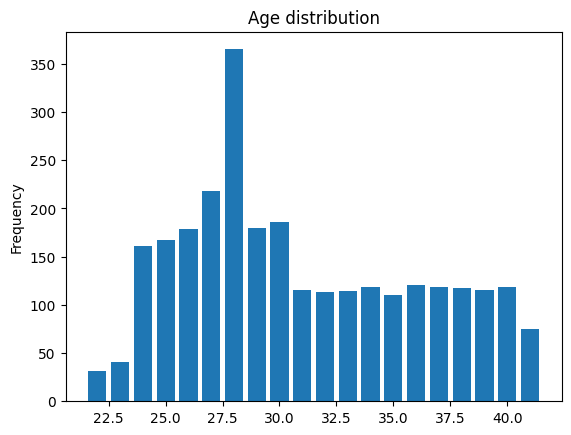

In [137]:
fig, ax = plt.subplots()
age_counts = df_clean["Age"].value_counts().sort_index()

ax.bar(age_counts.index, age_counts.values)

ax.set_ylabel("Frequency")
ax.set_title("Age distribution")
plt.show()


## What is the distribution of qualifications?

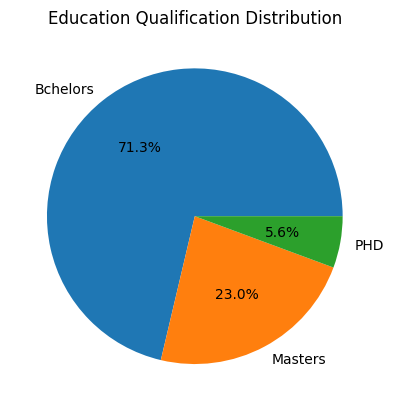

In [138]:
qualification_counts = df_clean["Education"].value_counts()
labels=["Bchelors", "Masters", "PHD"]

fig, ax = plt.subplots()
ax.pie(
    qualification_counts,
    labels= labels,
    autopct = '%1.1f%%',
 )

plt.title("Education Qualification Distribution")
plt.show()



The company has predominantly employed younger individuals, which is consistent with the finding that the majority of employees hold a Bachelor's degree

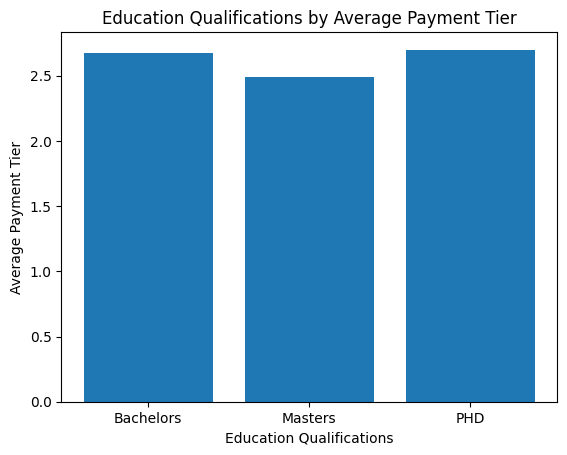

In [139]:
fig, ax = plt.subplots()
average_pay = df_clean.groupby("Education")["PaymentTier"].mean()

ax.bar(
    average_pay.index, 
    average_pay.values,
)

ax.set_xlabel("Education Qualifications")
ax.set_ylabel("Average Payment Tier")
ax.set_title("Education Qualifications by Average Payment Tier")

plt.show()

Employees across different education levels appear to have a similar Payment Tier, suggesting that education level has little influence on Payment Tier

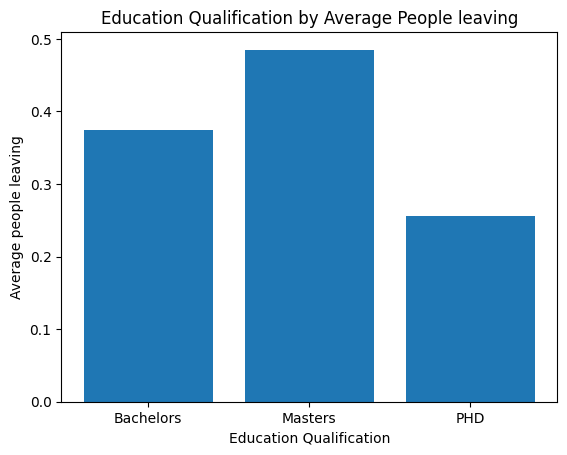

In [140]:
fig, ax = plt.subplots()
leaving_peop = df_clean.groupby("Education")["LeaveOrNot"].mean()

ax.bar(
    leaving_peop.index, 
    leaving_peop.values,
)

ax.set_xlabel("Education Qualification")
ax.set_ylabel("Average people leaving")
ax.set_title("Education Qualification by Average People leaving")

plt.show()

The visualisation shows that majority of people with a master's qualification are leaving the company. 

## Is gender evenly distributed in the workforce?

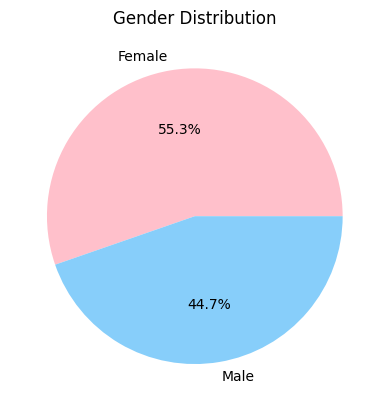

In [143]:
gender_counts = df_clean["Gender"].value_counts()
labels=["Female", "Male"]

fig, ax = plt.subplots()
ax.pie(
    gender_counts,
    labels= labels,
    autopct = '%1.1f%%',
    colors=["pink", "lightskyblue"] )

plt.title("Gender Distribution")
plt.show()

Gender
Female    2.516599
Male      2.732505
Name: PaymentTier, dtype: float64


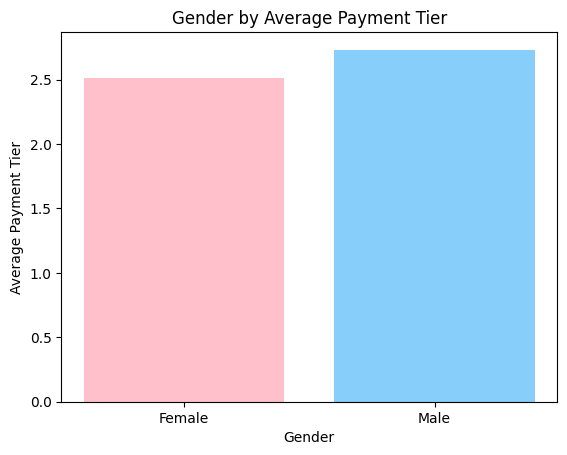

In [144]:
fig, ax = plt.subplots()
average_salary = df_clean.groupby("Gender")["PaymentTier"].mean()
colors=["pink", "lightskyblue"]

ax.bar(
    average_salary.index, 
    average_salary.values,
    color=colors
)


ax.set_xlabel("Gender")
ax.set_ylabel("Average Payment Tier")
ax.set_title("Gender by Average Payment Tier")

print(average_salary)

plt.show()

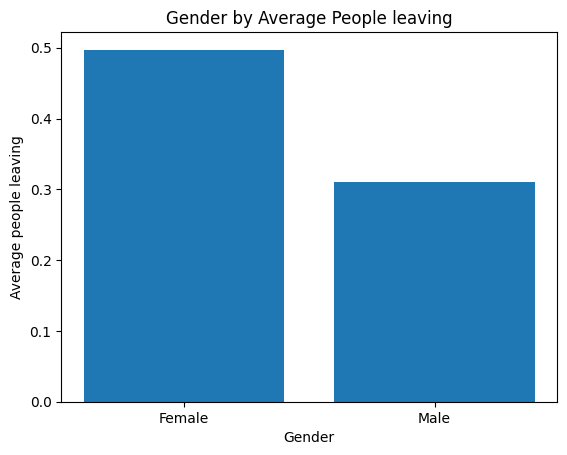

In [148]:
fig, ax = plt.subplots()
leaving_peop = df_clean.groupby("Gender")["LeaveOrNot"].mean()

ax.bar(
    leaving_peop.index, 
    leaving_peop.values,
)

ax.set_xlabel("Gender")
ax.set_ylabel("Average people leaving")
ax.set_title("Gender by Average People leaving")

plt.show()

The gender distribution is relatively even. Males have a slightly higher Payment Tier than females, while more female employees are leaving the company

City
Bangalore    0.350128
New Delhi    0.340909
Pune         0.509363
Name: LeaveOrNot, dtype: float64


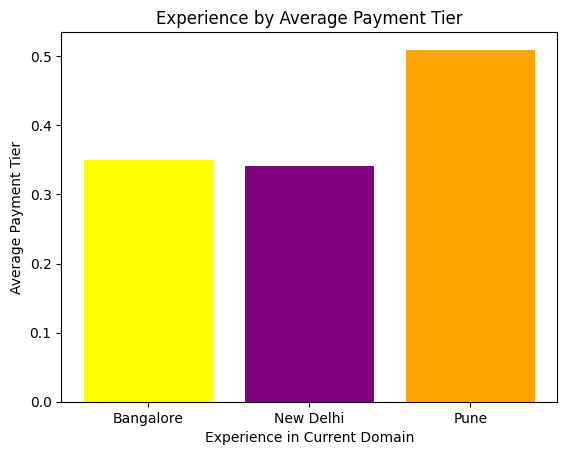

In [149]:
fig, ax = plt.subplots()
average_salary = df_clean.groupby("City")["LeaveOrNot"].mean()
colors=["yellow", "purple", "orange"]

ax.bar(
    average_salary.index, 
    average_salary.values,
    color=colors
)


ax.set_xlabel("Experience in Current Domain")
ax.set_ylabel("Average Payment Tier")
ax.set_title("Experience by Average Payment Tier")

print(average_salary)

plt.show()